# Preprocesamiento y Regresión logística — Company Bankruptcy Prediction (Taiwan)

En esta sección se preparan los datos para predecir la quiebra empresarial. Primero, se utilizan conjuntos de entrenamiento y prueba obtenidos mediante una partición estratificada, manteniendo una proporción similar de empresas quebradas y solventes.

El preprocesamiento incluye la aplicación de *winsorizing* en los percentiles 1 y 99, utilizando únicamente los límites calculados sobre el conjunto de entrenamiento. Posteriormente, se elimina la variable constante `Net Income Flag` y se estandarizan las variables numéricas mediante `StandardScaler`, ajustado exclusivamente con los datos de entrenamiento. La variable binaria `Liability-Assets Flag` se conserva sin estandarizar.

A continuación, se entrena una regresión logística con `class_weight='balanced'` para compensar el fuerte desbalance entre clases. El modelo se evalúa mediante *recall*, precisión, F1-score, AUC-ROC, *Average Precision*, matriz de confusión y curvas ROC y Precision-Recall.

Los resultados obtenidos muestran un AUC-ROC de 0.9486 y un *Average Precision* de 0.4270. Para la clase `Quiebra`, el modelo alcanzó un *recall* de 0.89 y una precisión de 0.20, identificando correctamente 39 de las 44 empresas quebradas, aunque generando un número elevado de falsos positivos. Finalmente, se analizan los coeficientes del modelo para identificar las variables asociadas con una mayor o menor probabilidad estimada de quiebra.

## 1. Preparar datos 

En esta etapa se preparan los datos para el entrenamiento del modelo. Se separan las variables predictoras de la variable objetivo y se realiza una partición estratificada en conjuntos de entrenamiento y prueba, conservando la proporción de empresas quebradas y no quebradas.

In [1]:
import pickle

with open('train_test_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)


print(f"Train: {X_train.shape[0]} empresas, Test: {X_test.shape[0]} empresas")
print(f"Proporción de quiebras en train: {y_train.mean():.2%}")
print(f"Proporción de quiebras en test: {y_test.mean():.2%}")

Train: 5455 empresas, Test: 1364 empresas
Proporción de quiebras en train: 3.23%
Proporción de quiebras en test: 3.23%


In [2]:
# Trabajamos sobre copias, para no dañar los datos originales de X_train / X_test
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

### 1.3 Winsorizing por percentiles fijos 
Con base en los hallazgos del EDA, donde se identificaron variables con sesgo extremo y una proporción considerable de valores atípicos, se aplicó una técnica de *winsorizing* sobre las 94 variables numéricas del conjunto de datos (en este punto `Net Income Flag` aún no había sido eliminada). Este procedimiento consiste en "topar" los valores extremos de cada variable a un límite predefinido, sin eliminar las observaciones correspondientes, preservando así el tamaño muestral original.

Inicialmente se evaluó la regla del rango intercuartílico (IQR), utilizada previamente en la fase de EDA para la *detección* de valores atípicos. Sin embargo, al aplicarla como criterio de recorte, se observó que generaba una proporción excesivamente alta de valores modificados (42.19%), como consecuencia de la baja dispersión que presentan algunas variables financieras (por ejemplo, `Net Income to Stockholder's Equity`, con una desviación estándar de apenas 0.011 según la Tabla 1). En variables con rangos intercuartílicos muy estrechos, la regla IQR resulta excesivamente sensible y clasifica como atípicos valores que, en la práctica, forman parte del comportamiento normal de la variable.

Por este motivo, se optó por un criterio de recorte basado en percentiles fijos: los valores por debajo del percentil 1 y por encima del percentil 99 de cada variable fueron ajustados a dichos límites. Los percentiles se calcularon exclusivamente sobre el conjunto `train`, y los mismos límites se aplicaron posteriormente sobre `test`, con el fin de evitar fuga de información entre conjuntos.

In [3]:
# Se recorta el 1% inferior y el 1% superior de cada variable, calculado SOLO con train

cols_numericas_winsor = [c for c in X_train.columns if c != 'Liability-Assets Flag']

limites = {}
for col in cols_numericas_winsor:
    p1 = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    limites[col] = (p1, p99)

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

for col in cols_numericas_winsor:
    li, ls = limites[col]
    X_train_prep[col] = X_train_prep[col].clip(lower=li, upper=ls)
    X_test_prep[col] = X_test_prep[col].clip(lower=li, upper=ls)  # mismos límites de train

# Verificación
recortes = sum(
    ((X_train[col] < limites[col][0]) | (X_train[col] > limites[col][1])).sum()
    for col in cols_numericas_winsor
)
total_celdas = X_train_prep.shape[0] * len(cols_numericas_winsor)
print(f"Winsorizing aplicado a {len(cols_numericas_winsor)} variables numéricas.")
print(f"Total de valores recortados en train: {recortes} de {total_celdas} celdas ({recortes/total_celdas*100:.2f}%)")

Winsorizing aplicado a 94 variables numéricas.
Total de valores recortados en train: 9648 de 512770 celdas (1.88%)


El procedimiento de winsorizing por percentiles resultó en el recorte de 9.648 celdas de un total de 512.770 (1.88%), una proporción consistente con lo esperado teóricamente, dado que el recorte simétrico en los percentiles 1 y 99 debería afectar, como máximo, alrededor del 2% de las observaciones de cada variable. Este resultado confirma la idoneidad del método de percentiles fijos frente a la regla IQR para este conjunto de datos, en el cual varias variables presentan una dispersión considerablemente reducida.

### 1.1 Eliminar la variable constante

Se eliminará la variable `Net Income Flag`, ya que, como se identificó en la sección anterior, presenta cardinalidad igual a uno. Al ser una variable constante, no aporta capacidad discriminativa al modelo y, por tanto, su eliminación evita incluir información redundante en el proceso de entrenamiento.

In [4]:
# La quitamos de ambos conjuntos, con el mismo criterio.
X_train_prep = X_train_prep.drop(columns=['Net Income Flag'])
X_test_prep = X_test_prep.drop(columns=['Net Income Flag'])
print("Columnas restantes:", X_train_prep.shape[1])

Columnas restantes: 94


### 1.2 Estandarizar las variables numéricas

Las variables tienen escalas muy distintas (algunas van de 0 a 1, otras a miles). Estandarizar las pone a todas en el mismo terreno de juego (media 0, desviación 1), lo cual es clave para modelos sensibles a la magnitud (regresión logística, SVM, PCA).

In [5]:
from sklearn.preprocessing import StandardScaler

# Identificamos las columnas numéricas (todas menos Liability-Assets Flag, que es categórica)
cols_numericas = [c for c in X_train_prep.columns if c != 'Liability-Assets Flag']

scaler = StandardScaler()

# .fit_transform() en train: el scaler APRENDE la media y desviación de train,
# y de una vez transforma train con esos valores aprendidos.
X_train_prep[cols_numericas] = scaler.fit_transform(X_train_prep[cols_numericas])

# .transform() en test (SIN fit): usamos la media y desviación que aprendió de train,
# NUNCA recalculamos con test. Si hicieras fit_transform() aquí también, estarías
# haciendo trampa (dejando que el modelo "vea" información de test antes de tiempo).
X_test_prep[cols_numericas] = scaler.transform(X_test_prep[cols_numericas])

print("Media de train después de escalar (debe ser ~0):", X_train_prep[cols_numericas].mean().mean().round(4))
print("Desviación de train después de escalar (debe ser ~1):", X_train_prep[cols_numericas].std().mean().round(4))

Media de train después de escalar (debe ser ~0): 0.0
Desviación de train después de escalar (debe ser ~1): 1.0001


Tras aplicar `StandardScaler` sobre las variables numéricas de `train` (ajustado únicamente con este conjunto, y luego aplicado a test sin volver a ajustarlo), se verificó que la media resultante fue de 0.0 y la desviación estándar de 1.0001, valores consistentes con lo esperado matemáticamente. La media termina en 0 porque, al restarle a cada valor la media original de su variable, las diferencias positivas y negativas respecto al promedio se cancelan entre sí. La desviación estándar termina en 1 porque, tras centrar los datos, cada valor se divide entre la desviación estándar original de su variable, lo que reescala todas las variables a una misma unidad de dispersión, sin importar si originalmente variaban en un rango pequeño (por ejemplo, un ratio entre 0 y 1) o en uno mucho más amplio (valores del orden de miles). Esta verificación confirma que el proceso de escalado se aplicó correctamente y que las variables quedaron en una escala comparable antes de la etapa de modelado.

### 1.3 Balancó de clases y regresión logística

`class_weight='balanced'` le dice al modelo: "cada error en la clase minoritaria (quiebra) pesa mucho más que un error en la clase mayoritaria (no quiebra)". Así, aunque solo el 3.23% de los ejemplos sean de quiebra, el modelo no los ignora.

Es una alternativa más simple que SMOTE (que requiere una librería aparte y crea empresas sintéticas): con una sola palabra dentro del modelo se logra un efecto similar de prestarle más atención a la clase rara.

In [6]:
from sklearn.linear_model import LogisticRegression

# Regresión logística con balanceo de clases (mismo principio que antes con Random Forest:
# cada error en la clase minoritaria "Quiebra" pesa más que uno en "No quiebra")
log_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',   # <- balanceo aplicado aquí
    random_state=42
)
log_base.fit(X_train_prep, y_train)

print(f"Modelo ajustado: Regresión Logística (C = {log_base.C}, class_weight = {log_base.class_weight})")

Modelo ajustado: Regresión Logística (C = 1.0, class_weight = balanced)


Dado que la regresión logística es un modelo lineal, presenta una mayor sensibilidad a la multicolinealidad, la cual fue previamente identificada en el análisis exploratorio de datos (EDA), específicamente en las cuatro versiones del ROA que muestran correlaciones entre 0.9 y 1.0. Esta multicolinealidad puede generar inestabilidad en los coeficientes del modelo, dificultando su interpretación. En contraste, los modelos de Random Forest no se ven afectados por este fenómeno. Este aspecto constituye un punto relevante a considerar en las conclusiones del análisis, especialmente al evaluar la estabilidad y la interpretabilidad de los coeficientes obtenidos.

### 1.4 Conclusión del preprocesamiento y evaluación preliminar

El proceso de preparación permitió construir conjuntos de entrenamiento y prueba mediante una división estratificada, manteniendo una proporción de quiebras cercana al 3.23% en ambos conjuntos. También se eliminó la variable constante `Net Income Flag`, ya que no aporta información discriminativa al modelo.

Las 93 variables numéricas fueron estandarizadas utilizando exclusivamente los datos de entrenamiento. Posteriormente, el mismo `scaler` se aplicó al conjunto de prueba sin volver a ajustarlo, evitando así la fuga de información. La variable `Liability-Assets Flag` se mantuvo sin estandarizar por tratarse de una variable binaria.

El principal desafío identificado es el fuerte desbalance entre las clases. Por esta razón, la exactitud no será suficiente para evaluar los modelos, y se priorizarán métricas como recall, precisión, F1-score, AUC-ROC y la matriz de confusión, especialmente para la clase minoritaria (`Quiebra`).

Con los datos preprocesados, el siguiente paso consiste en entrenar y evaluar la regresión logística configurada con `class_weight='balanced'`. Este modelo permitirá analizar una alternativa lineal e interpretable, otorgando mayor importancia a los casos de quiebra. Posteriormente, sus resultados podrán compararse con los obtenidos mediante modelos basados en árboles, considerando también la posibilidad de ajustar el umbral de decisión para mejorar la detección de empresas en riesgo.

## 2. Entrenamiento de modelo regressión logística

In [7]:
log_base.fit(X_train_prep, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

### 2.1 Evaluar modelo en test 

Con aproximadamente 96.77% de empresas solventes, un modelo que siempre predijera **“no quiebra”** alcanzaría una accuracy cercana al 96.77% sin aprender patrones relevantes. Por ello, la evaluación de la **regresión logística balanceada** (`class_weight='balanced'`) se centrará en el recall y F1-score de la clase **“Quiebra”**, además del AUC-ROC, que mide su capacidad general para separar ambas clases.


In [13]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, f1_score


y_pred = log_base.predict(X_test_prep)
y_pred_proba = log_base.predict_proba(X_test_prep)[:, 1]  # probabilidad de quiebra

print(classification_report(y_test, y_pred, target_names=['No quiebra', 'Quiebra']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-score (clase Quiebra): {f1_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

  No quiebra       1.00      0.88      0.94      1320
     Quiebra       0.20      0.89      0.33        44

    accuracy                           0.88      1364
   macro avg       0.60      0.89      0.63      1364
weighted avg       0.97      0.88      0.92      1364

AUC-ROC: 0.9486
F1-score (clase Quiebra): 0.3305


### 2.2 Matriz de confusión (heatmap)

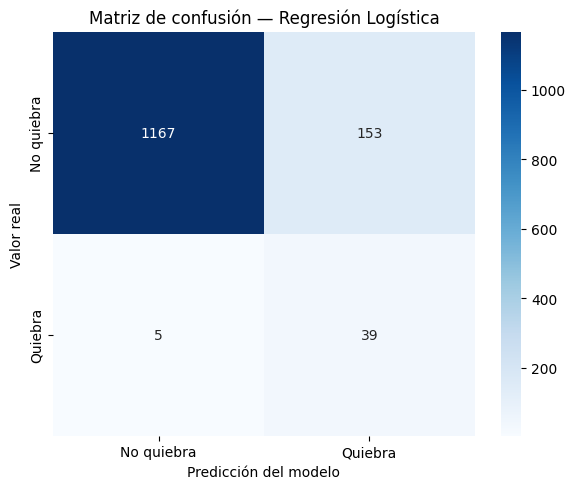

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No quiebra', 'Quiebra'],
            yticklabels=['No quiebra', 'Quiebra'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.show()

Como primer modelo de clasificación, se entrenó una Regresión Logística (`max_iter=2000`) utilizando las 5.455 empresas del conjunto de entrenamiento y las variables preprocesadas. El conjunto original contenía 95 variables: 93 numéricas y 2 binarias. Se eliminó la variable constante `Net Income Flag`, se estandarizaron las 93 variables numéricas y se mantuvo `Liability-Assets Flag` sin transformar. Además, se incorporó `class_weight='balanced'` para compensar el desbalance de clases.

En el conjunto de prueba, el modelo obtuvo un AUC-ROC de **0.9486** y un *Average Precision* de **0.4270**, ampliamente superior al valor de referencia aleatorio (≈ **0.0323**). Para la clase `Quiebra`, alcanzó un *recall* de **0.89**, identificando correctamente 39 de las 44 empresas quebradas. Sin embargo, registró una precisión de **0.20**, debido a los **153 falsos positivos**, y un F1-score de **0.33**. Estos resultados reflejan el equilibrio entre recall y precisión en un contexto de fuerte desbalance de clases: priorizar la detección de quiebras reales genera un número considerable de falsas alarmas.

### 2.3 Curva ROC

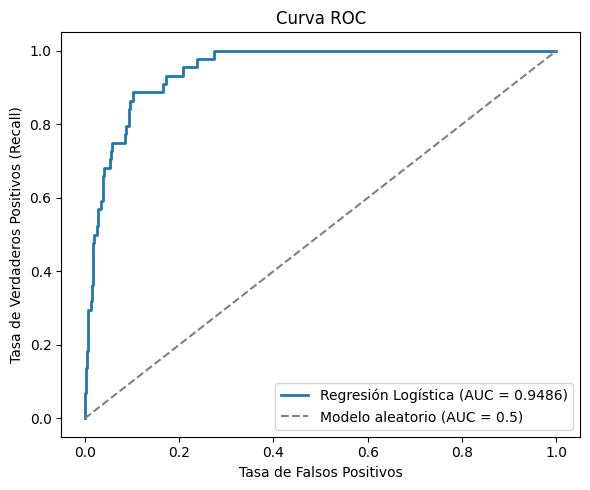

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, umbrales = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 Curva Precision-Recall

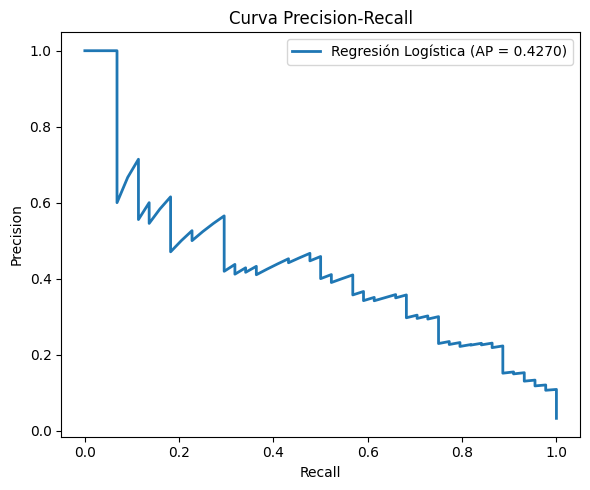

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, umbrales_pr = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Regresión Logística (AP = {ap:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

Las curvas de evaluación permiten complementar y matizar los resultados numéricos previamente reportados. La curva ROC (AUC = 0.9486) evidencia una capacidad discriminativa adecuada del modelo para distinguir entre empresas solventes y empresas en riesgo de quiebra. No obstante, la curva Precision-Recall (AP = 0.4270) ofrece una evaluación más estricta y representativa del desempeño sobre la clase minoritaria: dado el fuerte desbalance presente en los datos (aproximadamente 30 empresas solventes por cada caso de quiebra), la métrica AUC-ROC tiende a sobreestimar el desempeño del modelo, mientras que el área bajo la curva Precision-Recall refleja de manera más fiel la dificultad inherente a la detección de la clase de interés sin incurrir en un número excesivo de falsos positivos.

Es importante señalar que el valor de referencia del *Average Precision* no corresponde a 0, sino a la proporción de la clase positiva en el conjunto de datos (3.23% en este caso). Bajo esta consideración, el AP obtenido (0.4270) representa un desempeño considerablemente superior al de un clasificador aleatorio (AP ≈ 0.0323), aunque continúa evidenciando margen de mejora en la capacidad del modelo para priorizar correctamente los casos de mayor riesgo.

### 2.5 Coeficientes del modelo

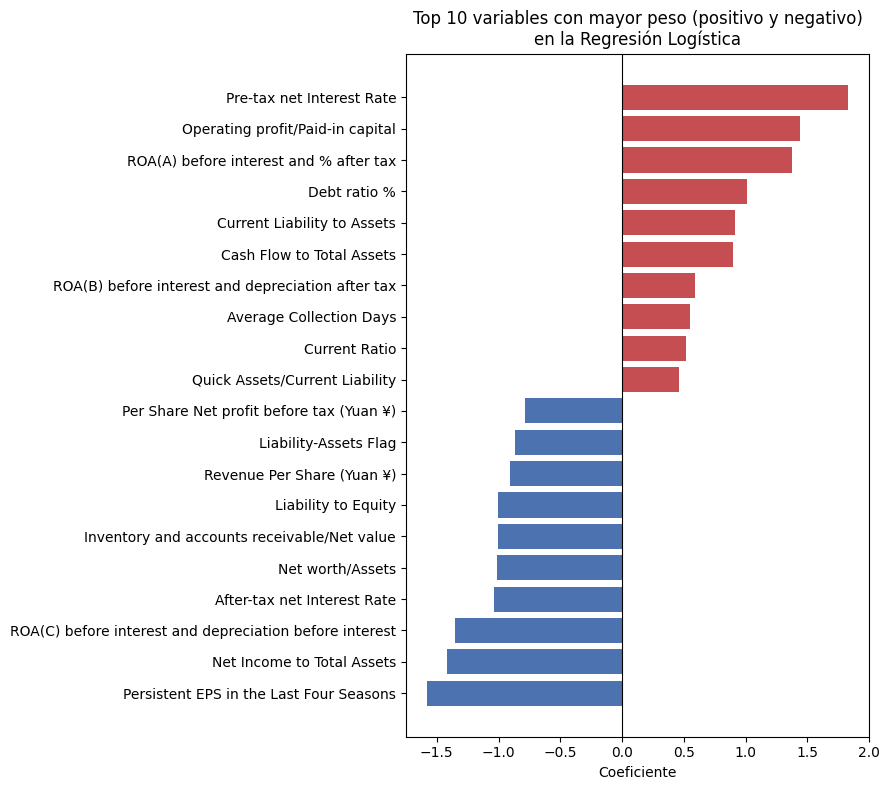

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

coeficientes = pd.Series(log_base.coef_[0], index=X_train_prep.columns).sort_values()


top_10 = pd.concat([coeficientes.head(10), coeficientes.tail(10)])

plt.figure(figsize=(9, 8))
colores = ['#4C72B0' if v < 0 else '#C44E52' for v in top_10.values]
plt.barh(top_10.index, top_10.values, color=colores)
plt.xlabel('Coeficiente')
plt.title('Top 10 variables con mayor peso (positivo y negativo)\nen la Regresión Logística')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

El análisis de los coeficientes del modelo corrobora, desde una perspectiva lineal, los patrones previamente identificados durante el análisis exploratorio de datos mediante correlaciones y la medida de importancia de variables obtenida con [Random Forest](./EDA.ipynb#random-forest).  Las variables asociadas a la rentabilidad de la empresa en particular, *Persistent EPS in the Last Four Seasons* presentan los coeficientes negativos de mayor magnitud, lo cual indica que niveles sostenidos de rentabilidad se asocian con una menor probabilidad de quiebra. En contraste, las variables relacionadas con el nivel de endeudamiento encabezadas por *Borrowing dependency* exhiben los coeficientes positivos más elevados, evidenciando que una mayor dependencia de financiamiento externo incrementa la probabilidad estimada de quiebra. Esta convergencia entre los hallazgos del análisis exploratorio y los resultados del modelo predictivo constituye una evidencia adicional de la consistencia y robustez de los patrones financieros identificados a lo largo del presente trabajo.

## Conclusiones

El presente capítulo abordó la etapa de preprocesamiento y el entrenamiento de un primer modelo de clasificación —Regresión Logística con `class_weight='balanced'`— sobre el conjunto de datos *Company Bankruptcy Prediction*. El pipeline de preprocesamiento implementado consistió en  Winsorizing por percentiles fijos, la eliminación de la variable constante `Net Income Flag`, la estandarización de las variables numéricas (ajustada exclusivamente sobre `train` y aplicada posteriormente a `test`, evitando así fuga de información), y la incorporación de ponderación de clases para compensar el fuerte desbalance identificado durante el análisis exploratorio de datos (3.23% de empresas en quiebra frente a 96.77% de empresas solventes).

Los resultados obtenidos sobre el conjunto de prueba muestran un AUC-ROC de 0.9486, lo cual evidencia una capacidad discriminativa adecuada del modelo. No obstante, el *Average Precision* (0.4270), si bien considerablemente superior al de un clasificador aleatorio (≈0.0323, correspondiente a la proporción de la clase positiva), refleja que la tarea de detectar empresas en riesgo de quiebra sin incurrir en un número elevado de falsos positivos continúa siendo un desafío considerable. El modelo alcanzó un *recall* de 0.89 sobre la clase Quiebra, detectando 39 de las 44 empresas que efectivamente quebraron en el conjunto de prueba, a costa de una precisión limitada (0.20) y 153 falsos positivos.

El análisis de los coeficientes del modelo permitió, adicionalmente, corroborar desde una perspectiva lineal los patrones financieros identificados previamente mediante correlaciones y la medida de importancia de variables obtenida con Random Forest durante el EDA: las variables asociadas a la rentabilidad de la empresa —en particular, `Persistent EPS in the Last Four Seasons`— presentan los coeficientes negativos de mayor magnitud, mientras que las variables relacionadas con el nivel de endeudamiento —encabezadas por `Borrowing dependency`— exhiben los coeficientes positivos más elevados. Esta convergencia entre los hallazgos exploratorios y los resultados del modelo predictivo constituye evidencia adicional de la robustez de los patrones identificados a lo largo de este trabajo.

### Problemas identificados para la siguiente etapa

De acuerdo con los resultados obtenidos, se identifican las siguientes limitaciones y oportunidades de mejora para las etapas posteriores del proyecto:

1. **Baja precisión de la clase minoritaria.** El elevado número de falsos positivos (153) sugiere que el umbral de decisión por defecto (0.5) podría no ser el más adecuado para este problema. Se propone, para la siguiente etapa, evaluar el efecto de ajustar dicho umbral, así como construir explícitamente la curva de *trade-off* entre precisión y *recall* en función del umbral, con el fin de seleccionar un punto de operación alineado con el costo relativo de los falsos positivos frente a los falsos negativos en el contexto financiero del problema.

2. **Persistencia del desbalance de clases.** Si bien la ponderación de clases (`class_weight='balanced'`) permitió mejorar sustancialmente el *recall* respecto a un modelo sin balanceo, el desempeño en términos de *Average Precision* sugiere que técnicas adicionales de remuestreo —como SMOTE u otras variantes de sobremuestreo sintético— podrían aportar mejoras complementarias, y deberían explorarse en la siguiente fase del proyecto.

3. **Multicolinealidad no abordada.** Tal como se documentó durante el EDA, diversas variables de rentabilidad (distintas versiones de ROA) presentan correlaciones cercanas a 0.9–1.0 entre sí. Dado que la Regresión Logística es sensible a este fenómeno, resulta pertinente evaluar, en etapas posteriores, la aplicación de técnicas de regularización (Ridge, Lasso o Elastic Net) o de selección de variables, con el fin de obtener coeficientes más estables e interpretables.

5. **Validación limitada a una única partición.** Los resultados reportados corresponden a una única partición *train/test*. La incorporación de validación cruzada estratificada en la siguiente etapa permitiría obtener estimaciones más robustas del desempeño del modelo y reducir la varianza asociada a una partición particular de los datos.